In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

In [2]:
# Load Murarka et al. (2021) dataset - combine train, val, test splits
murarka_train = pd.read_csv("datasets/raw/both_train.csv")
murarka_val = pd.read_csv("datasets/raw/both_val.csv")
murarka_test = pd.read_csv("datasets/raw/both_test.csv")


# Combine all Murarka splits
murarka_df = pd.concat([murarka_train, murarka_val, murarka_test], ignore_index=True)
murarka_df.head()

,ID,title,post,class_name,class_id
0,691324c4-5c30-44e0-b9e4-45b4f0715e21,a question about the third conditional.,i was making questions for my students and i ran into a little tricky grammar. which is correct ...,none,5
1,d4295391-9ca5-4398-b7c8-687e4a984ef1,the epitome of my life,i've recently requested testing accommodations at my university and was given letters to persona...,adhd,0
2,58937fa5-3c2c-426b-8255-5a140fbab675,what are your favourites offbeat destinations of asia? this is my list.,**cambodia** * koh rong: amazing beaches and a very serene romantic island * kratie: very beauti...,none,5
3,7daf364c-3b33-4cbe-be37-a214edf9a73e,synesthesia survey (what colour is each month to you?),"synesthesia. what is synesthesia? according to google, ""synesthesia is a condition in which one ...",none,5
4,22518271-4bb4-4caf-b683-7305da519288,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",i’m phil baran and i teach organic chemistry at the scripps research institute. i also head the ...,none,5


In [3]:
print("=== Murarka Label Analysis ===")
print(f"\nUnique class_name values:\n{murarka_df['class_name'].value_counts()}")
print(f"\nUnique class_id values:\n{murarka_df['class_id'].value_counts().sort_index()}")

print(f"\nNull values:\n{murarka_df.isnull().sum()}")

=== Murarka Label Analysis ===

Unique class_name values:
adhd          2961
depression    2946
anxiety       2918
bipolar       2903
ptsd          2497
none          2478
Name: class_name, dtype: int64

Unique class_id values:
0    2961
1    2918
2    2903
3    2946
4    2497
5    2478
Name: class_id, dtype: int64

Null values:
ID            0
title         0
post          0
class_name    0
class_id      0
dtype: int64


In [4]:
sarkar_df = pd.read_csv("datasets/raw/Combined Data.csv", index_col=0)

print("=== Sarkar Dataset ===")
print(f"Shape: {sarkar_df.shape}")
print(f"\nColumns: {list(sarkar_df.columns)}")
print(f"\nFirst few rows:")
sarkar_df.head()

=== Sarkar Dataset ===
Shape: (53043, 2)

Columns: ['statement', 'status']

First few rows:


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless heart. All out of tune",Anxiety
2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",Anxiety
3,I've shifted my focus to something else but I'm still worried,Anxiety
4,"I'm restless and restless, it's been a month now, boy. What do you mean?",Anxiety


In [5]:
SHARED_LABELS = ['Depression', 'Anxiety', 'Bipolar', 'ADHD', 'PTSD', 'None']

def map_murarka_label(label):
    label_map = {
        'adhd': 'ADHD',
        'anxiety': 'Anxiety',
        'bipolar': 'Bipolar',
        'depression': 'Depression',
        'none': 'None',
        'ptsd': 'PTSD'
    }
    return label_map.get(label.lower(), label)

def map_sarkar_label(label):
    label_map = {
        'Depression': 'Depression',
        'Anxiety': 'Anxiety',
        'Bipolar': 'Bipolar',
        'ADHD': 'ADHD',
        'PTSD': 'PTSD',
        'Normal': 'None',
        'Personality disorder': 'None',  
        'Stress': 'None',  
        'Suicidal': 'Depression'  
    }
    return label_map.get(label, label)


In [6]:
murarka_df['text'] = murarka_df['title'].fillna('') + ' ' + murarka_df['post'].fillna('')
murarka_df['text'] = murarka_df['text'].str.strip()

murarka_df['label'] = murarka_df['class_name'].apply(map_murarka_label)
murarka_df['source'] = 'Murarka'

murarka_clean = murarka_df[['text', 'label', 'source']].copy()

murarka_clean.head()

,text,label,source
0,a question about the third conditional. i was making questions for my students and i ran into a ...,None,Murarka
1,the epitome of my life i've recently requested testing accommodations at my university and was g...,ADHD,Murarka
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong:...,None,Murarka
3,synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? accordi...,None,Murarka
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",None,Murarka


In [7]:
sarkar_df['text'] = sarkar_df['statement'].fillna('').str.strip()

sarkar_df['label'] = sarkar_df['status'].apply(map_sarkar_label)

sarkar_df['source'] = 'Sarkar'

sarkar_clean = sarkar_df[['text', 'label', 'source']].copy()

sarkar_clean.head()

,text,label,source
0,oh my gosh,Anxiety,Sarkar
1,"trouble sleeping, confused mind, restless heart. All out of tune",Anxiety,Sarkar
2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",Anxiety,Sarkar
3,I've shifted my focus to something else but I'm still worried,Anxiety,Sarkar
4,"I'm restless and restless, it's been a month now, boy. What do you mean?",Anxiety,Sarkar


In [14]:
combined_df = pd.concat([murarka_clean, sarkar_clean], ignore_index=True)

combined_df = combined_df.dropna(subset=['text', 'label'])

combined_df = combined_df[combined_df['text'].str.strip() != '']

combined_df

,text,label,source
0,a question about the third conditional. i was making questions for my students and i ran into a ...,None,Murarka
1,the epitome of my life i've recently requested testing accommodations at my university and was g...,ADHD,Murarka
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong:...,None,Murarka
3,synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? accordi...,None,Murarka
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",None,Murarka
...,...,...,...
69741,Nobody takes me seriously I’ve (24M) dealt with depression/anxiety for years now. I used to be g...,Anxiety,Sarkar
69742,"selfishness ""I don't feel very good, it's like I don't belong in this world (I don't think I ev...",Anxiety,Sarkar
69743,"Is there any way to sleep better? I can't sleep most of the nights, meds didn't help.",Anxiety,Sarkar
69744,"Public speaking tips? Hi, all. I have to give a presentation at work next week (45 minutes long ...",Anxiety,Sarkar


In [15]:
duplicates = combined_df['text'].duplicated().sum()

combined_df = combined_df.drop_duplicates(subset=['text'], keep='first')
print(f"Removed {duplicates} duplicate texts")

Removed 1614 duplicate texts


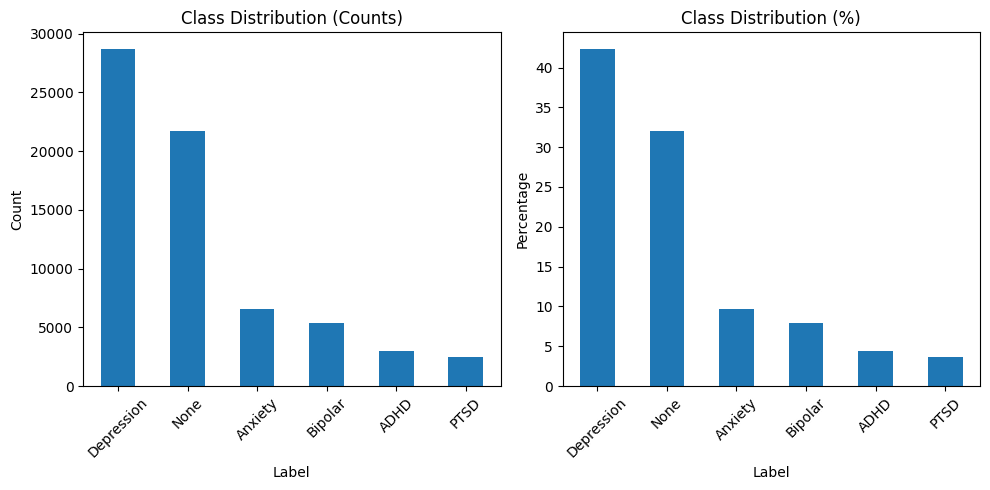

In [10]:
label_counts = combined_df['label'].value_counts()

label_pct = combined_df['label'].value_counts(normalize=True) * 100

max_count = label_counts.max()
class_weights = {label: max_count / count for label, count in label_counts.items()}

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar')
plt.title('Class Distribution (Counts)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
label_pct.plot(kind='bar')
plt.title('Class Distribution (%)')
plt.xlabel('Label')
plt.ylabel('Percentage')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
combined_df['word_count'] = combined_df['text'].apply(lambda x: len(str(x).split()))

short_posts = combined_df[combined_df['word_count'] < 5]

p99 = combined_df['word_count'].quantile(0.99)
long_posts = combined_df[combined_df['word_count'] > p99]

In [12]:

combined_df = combined_df[combined_df['word_count'] >= 5]


# Drop the word_count column (was just for analysis)
combined_df = combined_df.drop(columns=['word_count'])


In [18]:
# Save to processed folder
output_path = "datasets/processed/mental_health_cleaned.csv"
combined_df.to_csv(output_path, index=False)

combined_df.sample(5, random_state=42)

,text,label,source
21848,"I'm here, so I'm in a rush, so I'm going to get sued here",None,Sarkar
29557,"He said he was falling to a black hole, and he would not want to meet me and needed to be alone....",Depression,Sarkar
69445,I managed to overpower my anxiety and send an email to a complete stranger. I know it doesn't so...,Anxiety,Sarkar
41422,Oh Ill just drop this class and lose this scholarship haha ill just kill myself next month to oh...,Depression,Sarkar
34427,"No one actually cares its so depressing, no real friends or anyone to talk to. I feel like such ...",Depression,Sarkar
